In [1]:
import numpy
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch.optim as optim
import torch.nn as nn

from torch.utils.data import random_split
from torch.utils.data import DataLoader

In [2]:
import torch

print(torch.__version__)
print("CUDA dostępna:", torch.cuda.is_available())
print("Wersja CUDA w torch:", torch.version.cuda)
print("Liczba GPU:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.7.1+cu118
CUDA dostępna: True
Wersja CUDA w torch: 11.8
Liczba GPU: 1
GPU: NVIDIA GeForce GTX 1060 3GB


In [3]:
torch.manual_seed(42)  # For reproducibility

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
from pathlib import Path

base = Path("data/prepared_data256")

print("Czy istnieje base?", base.exists())
print("Czy istnieje images?", (base / "images").exists())
print("Czy istnieje masks?", (base / "masks").exists())

print("Pliki w base:")
print(list(base.glob("*")))

print("Pliki w images:")
print(list((base / "images").glob("*"))[:10])

print("Pliki w masks:")
print(list((base / "masks").glob("*"))[:10])

Czy istnieje base? True
Czy istnieje images? True
Czy istnieje masks? True
Pliki w base:
[WindowsPath('data/prepared_data256/images'), WindowsPath('data/prepared_data256/masks')]
Pliki w images:
[WindowsPath('data/prepared_data256/images/image_part_001_0.png'), WindowsPath('data/prepared_data256/images/image_part_001_1.png'), WindowsPath('data/prepared_data256/images/image_part_001_10.png'), WindowsPath('data/prepared_data256/images/image_part_001_11.png'), WindowsPath('data/prepared_data256/images/image_part_001_12.png'), WindowsPath('data/prepared_data256/images/image_part_001_13.png'), WindowsPath('data/prepared_data256/images/image_part_001_14.png'), WindowsPath('data/prepared_data256/images/image_part_001_15.png'), WindowsPath('data/prepared_data256/images/image_part_001_16.png'), WindowsPath('data/prepared_data256/images/image_part_001_17.png')]
Pliki w masks:
[WindowsPath('data/prepared_data256/masks/image_part_001_0.png'), WindowsPath('data/prepared_data256/masks/image_part_001

In [5]:
from pathlib import Path
from sklearn.model_selection import train_test_split

images = sorted(Path("data/prepared_data256/images").glob("*.png"))
masks = sorted(Path("data/prepared_data256/masks").glob("*.png"))

pairs = list(zip(images, masks))
print(pairs)
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

[(WindowsPath('data/prepared_data256/images/image_part_001_0.png'), WindowsPath('data/prepared_data256/masks/image_part_001_0.png')), (WindowsPath('data/prepared_data256/images/image_part_001_1.png'), WindowsPath('data/prepared_data256/masks/image_part_001_1.png')), (WindowsPath('data/prepared_data256/images/image_part_001_10.png'), WindowsPath('data/prepared_data256/masks/image_part_001_10.png')), (WindowsPath('data/prepared_data256/images/image_part_001_11.png'), WindowsPath('data/prepared_data256/masks/image_part_001_11.png')), (WindowsPath('data/prepared_data256/images/image_part_001_12.png'), WindowsPath('data/prepared_data256/masks/image_part_001_12.png')), (WindowsPath('data/prepared_data256/images/image_part_001_13.png'), WindowsPath('data/prepared_data256/masks/image_part_001_13.png')), (WindowsPath('data/prepared_data256/images/image_part_001_14.png'), WindowsPath('data/prepared_data256/masks/image_part_001_14.png')), (WindowsPath('data/prepared_data256/images/image_part_001_

In [6]:
import random
import torchvision.transforms.functional as TF

class SegementationTransform():
    def __init__(self,hflip_prob=0.5,vflip_prob=0.5):
        self.hflip_prob = hflip_prob
        self.vflip_prob =vflip_prob

In [7]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torchvision.transforms.functional as TF


class AerialSegemntationDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transform is not None:
            image, mask = self.transform(image, mask)

        image = TF.to_tensor(image)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)

        return image, mask

In [8]:
from torch.utils.data import DataLoader

train_dataset = AerialSegemntationDataset(train_pairs)

train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True,num_workers=0)

val_dataset = AerialSegemntationDataset(val_pairs)

val_loader = DataLoader(val_dataset,batch_size=8,shuffle=False,num_workers=0)

test_dataset = AerialSegemntationDataset(test_pairs)

test_loader = DataLoader(test_dataset,batch_size=8,shuffle=False,num_workers=0)

In [9]:
class UNet(nn.Module):
    def __init__(self, n_class,inuput_channels):
        super().__init__()
        #Encoding
        self.e11 = nn.Conv2d(inuput_channels, 64, kernel_size=3, padding=1, bias=False)
        self.e12 = nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False)
        self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e21 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.e22 = nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False)
        self.pool2 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e31 = nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False)
        self.e32 = nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False)
        self.pool3 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e41 = nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False)
        self.e42 = nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False)
        self.pool4 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e51 = nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False)
        self.e52 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias=False)

        #Decoding
        self.upconv1 = nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2)
        self.d11 = nn.Conv2d(1024,512,kernel_size=3, padding=1)
        self.d12 = nn.Conv2d(512,512,kernel_size=3, padding=1)

        self.upconv2 = nn.ConvTranspose2d(512,256,kernel_size=2,stride=2)
        self.d21 = nn.Conv2d(512,256,kernel_size=3, padding=1)
        self.d22 = nn.Conv2d(256,256,kernel_size=3, padding=1)

        self.upconv3 = nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
        self.d31 = nn.Conv2d(256,128,kernel_size=3, padding=1)
        self.d32 = nn.Conv2d(128,128,kernel_size=3, padding=1)

        self.upconv4 = nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
        self.d41 = nn.Conv2d(128,64,kernel_size=3, padding=1)
        self.d42 = nn.Conv2d(64,64,kernel_size=3, padding=1)

        #out
        self.outconv= nn.Conv2d(64,n_class,kernel_size=1)

    def forward(self,x):
        #encoder
        xe11 = nn.functional.relu(self.e11(x))
        xe12 = nn.functional.relu(self.e12(xe11))
        xp1 = self.pool1(xe12)

        xe21 = nn.functional.relu(self.e21(xp1))
        xe22 = nn.functional.relu(self.e22(xe21))
        xp2 = self.pool1(xe22)

        xe31 = nn.functional.relu(self.e31(xp2))
        xe32 = nn.functional.relu(self.e32(xe31))
        xp3 = self.pool1(xe32)

        xe41 = nn.functional.relu(self.e41(xp3))
        xe42 = nn.functional.relu(self.e42(xe41))
        xp4 = self.pool1(xe42)

        xe51 = nn.functional.relu(self.e51(xp4))
        xe52 = nn.functional.relu(self.e52(xe51))

        #decoder
        xu1 = self.upconv1(xe52)
        xu11 = torch.cat([xu1,xe42],dim=1)
        xd11 = nn.functional.relu(self.d11(xu11))
        xd12 = nn.functional.relu(self.d12(xd11))

        xu2 = self.upconv2(xd12)
        xu21 = torch.cat([xu2,xe32],dim=1)
        xd21 = nn.functional.relu(self.d21(xu21))
        xd22 = nn.functional.relu(self.d22(xd21))

        xu3 = self.upconv3(xd22)
        xu31 = torch.cat([xu3,xe22],dim=1)
        xd31 = nn.functional.relu(self.d31(xu31))
        xd32 = nn.functional.relu(self.d32(xd31))

        xu4 = self.upconv4(xd32)
        xu41 = torch.cat([xu4,xe12],dim=1)
        xd41 = nn.functional.relu(self.d41(xu41))
        xd42 = nn.functional.relu(self.d42(xd41))

        #out
        out = self.outconv(xd42)

        return out

        

In [10]:
import copy
import os
import numpy as np


class Trainer():
    def __init__(self,
                 model,
                 train_loader,
                 val_loader,
                 test_loader,
                 criterion,
                 optimizer,
                 num_epochs,
                 num_classes=6,
                 ignore_class_for_mean=5,
                 early_stopping=True,
                 patience=8,
                 min_delta=0.001,
                 monitor="val_miou",
                 mode="max",
                 best_model_path="saved_models/unet_aerial_best_checkpoint.pth"):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.num_epochs = num_epochs
        self.num_classes = num_classes
        self.ignore_class_for_mean = ignore_class_for_mean

        # Early stopping
        self.early_stopping = early_stopping
        self.patience = patience
        self.min_delta = min_delta
        self.monitor = monitor
        self.mode = mode
        self.best_model_path = best_model_path
        self.best_value = None
        self.best_epoch = 0
        self.best_model_state = None
        self.epochs_without_improvement = 0

        self.train_loss_hist = []
        self.val_loss_hist = []
        self.train_miou_hist = []
        self.val_miou_hist = []
        self.train_dice_hist = []
        self.val_dice_hist = []
        self.train_pixel_acc_hist = []
        self.val_pixel_acc_hist = []

    @staticmethod
    def safe_divide(numerator, denominator):
        numerator = np.asarray(numerator, dtype=np.float64)
        denominator = np.asarray(denominator, dtype=np.float64)
        return np.divide(
            numerator,
            denominator,
            out=np.full_like(numerator, np.nan, dtype=np.float64),
            where=denominator != 0
        )

    def _empty_confusion_matrix(self):
        return torch.zeros((self.num_classes, self.num_classes), dtype=torch.int64)

    def _update_confusion_matrix(self, confusion_matrix, preds, masks):
        true = masks.detach().view(-1).cpu()
        pred = preds.detach().view(-1).cpu()

        valid = (
            (true >= 0) &
            (true < self.num_classes) &
            (pred >= 0) &
            (pred < self.num_classes)
        )

        true = true[valid]
        pred = pred[valid]

        encoded = self.num_classes * true + pred
        confusion_matrix += torch.bincount(
            encoded,
            minlength=self.num_classes ** 2
        ).reshape(self.num_classes, self.num_classes)

        return confusion_matrix

    def _metrics_from_confusion_matrix(self, confusion_matrix):
        cm = confusion_matrix.numpy().astype(np.float64)
        total_pixels = cm.sum()

        if total_pixels == 0:
            return {
                "pixel_accuracy": np.nan,
                "mean_iou": np.nan,
                "mean_dice": np.nan,
                "iou_per_class": np.full(self.num_classes, np.nan),
                "dice_per_class": np.full(self.num_classes, np.nan),
            }

        tp = np.diag(cm)
        support = cm.sum(axis=1)
        predicted = cm.sum(axis=0)

        fp = predicted - tp
        fn = support - tp

        iou = self.safe_divide(tp, tp + fp + fn)
        dice = self.safe_divide(2 * tp, 2 * tp + fp + fn)
        pixel_accuracy = float(self.safe_divide(tp.sum(), total_pixels))

        valid_classes_for_mean = support > 0
        if self.ignore_class_for_mean is not None:
            valid_classes_for_mean[self.ignore_class_for_mean] = False

        mean_iou = float(np.nanmean(iou[valid_classes_for_mean]))
        mean_dice = float(np.nanmean(dice[valid_classes_for_mean]))

        return {
            "pixel_accuracy": pixel_accuracy,
            "mean_iou": mean_iou,
            "mean_dice": mean_dice,
            "iou_per_class": iou,
            "dice_per_class": dice,
        }

    def training_epoch(self, data_loader):
        self.model.train()
        running_loss = 0.0
        confusion_matrix = self._empty_confusion_matrix()

        for image, mask in data_loader:
            image, mask = image.to(device), mask.to(device)

            self.optimizer.zero_grad()
            out = self.model(image)
            loss = self.criterion(out, mask)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            pred = torch.argmax(out, dim=1)
            confusion_matrix = self._update_confusion_matrix(confusion_matrix, pred, mask)

        loss = running_loss / len(data_loader)
        metrics = self._metrics_from_confusion_matrix(confusion_matrix)
        return loss, metrics

    def evaluate(self, data_loader):
        self.model.eval()
        running_loss = 0.0
        confusion_matrix = self._empty_confusion_matrix()

        with torch.no_grad():
            for image, mask in data_loader:
                image, mask = image.to(device), mask.to(device)

                out = self.model(image)
                loss = self.criterion(out, mask)

                running_loss += loss.item()
                pred = torch.argmax(out, dim=1)
                confusion_matrix = self._update_confusion_matrix(confusion_matrix, pred, mask)

        loss = running_loss / len(data_loader)
        metrics = self._metrics_from_confusion_matrix(confusion_matrix)
        return loss, metrics

    def _current_monitor_value(self, val_loss, val_metrics):
        values = {
            "val_loss": val_loss,
            "val_miou": val_metrics["mean_iou"],
            "val_dice": val_metrics["mean_dice"],
            "val_pixel_accuracy": val_metrics["pixel_accuracy"],
        }

        if self.monitor not in values:
            raise ValueError(
                f"Nieznana metryka monitorowana: {self.monitor}. "
                f"Dostępne opcje: {list(values.keys())}"
            )

        return values[self.monitor]

    def _is_improvement(self, current_value):
        if self.best_value is None:
            return True

        if self.mode == "min":
            return current_value < self.best_value - self.min_delta

        if self.mode == "max":
            return current_value > self.best_value + self.min_delta

        raise ValueError("Parametr mode musi mieć wartość 'min' albo 'max'.")

    def _save_best_model(self, epoch, current_value):
        self.best_value = current_value
        self.best_epoch = epoch
        self.best_model_state = copy.deepcopy(self.model.state_dict())

        directory = os.path.dirname(self.best_model_path)
        if directory:
            os.makedirs(directory, exist_ok=True)

        torch.save({
            "epoch": epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "monitor": self.monitor,
            "best_value": self.best_value,
            "history": self.get_history(),
        }, self.best_model_path)

    def train(self):
        print(
            f"Early stopping: {'włączony' if self.early_stopping else 'wyłączony'} | "
            f"monitor={self.monitor}, mode={self.mode}, patience={self.patience}, min_delta={self.min_delta}"
        )

        for epoch in range(1, self.num_epochs + 1):
            train_loss, train_metrics = self.training_epoch(self.train_loader)
            val_loss, val_metrics = self.evaluate(self.val_loader)

            self.train_loss_hist.append(train_loss)
            self.val_loss_hist.append(val_loss)
            self.train_miou_hist.append(train_metrics["mean_iou"])
            self.val_miou_hist.append(val_metrics["mean_iou"])
            self.train_dice_hist.append(train_metrics["mean_dice"])
            self.val_dice_hist.append(val_metrics["mean_dice"])
            self.train_pixel_acc_hist.append(train_metrics["pixel_accuracy"])
            self.val_pixel_acc_hist.append(val_metrics["pixel_accuracy"])

            current_value = self._current_monitor_value(val_loss, val_metrics)

            print(
                f"Epoch [{epoch}/{self.num_epochs}] | "
                f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} | "
                f"Train mIoU: {train_metrics['mean_iou']:.4f}, Val mIoU: {val_metrics['mean_iou']:.4f} | "
                f"Train Dice: {train_metrics['mean_dice']:.4f}, Val Dice: {val_metrics['mean_dice']:.4f} | "
                f"Train Acc: {train_metrics['pixel_accuracy']:.4f}, Val Acc: {val_metrics['pixel_accuracy']:.4f}"
            )

            if self._is_improvement(current_value):
                self._save_best_model(epoch, current_value)
                self.epochs_without_improvement = 0
                print(f"  -> Nowy najlepszy model zapisany: {self.monitor} = {current_value:.4f}")
            else:
                self.epochs_without_improvement += 1
                print(
                    f"  -> Brak poprawy: {self.epochs_without_improvement}/{self.patience} "
                    f"(najlepszy wynik z epoki {self.best_epoch}: {self.best_value:.4f})"
                )

                if self.early_stopping and self.epochs_without_improvement >= self.patience:
                    print(f"Early stopping zatrzymał trening po epoce {epoch}.")
                    break

        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            print(
                f"Przywrócono najlepszy model z epoki {self.best_epoch} "
                f"({self.monitor} = {self.best_value:.4f})."
            )
            print(f"Checkpoint najlepszego modelu: {self.best_model_path}")

    def show_history(self):
        epochs = range(1, len(self.train_loss_hist) + 1)

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        axes[0].plot(epochs, np.array(self.train_loss_hist), label='Train Loss')
        axes[0].plot(epochs, np.array(self.val_loss_hist), label='Val Loss')
        axes[0].set_title("Trening: funkcja straty")
        axes[0].set_xlabel("Epoka")
        axes[0].set_ylabel("Loss")
        axes[0].legend()

        axes[1].plot(epochs, np.array(self.train_miou_hist), label='Train mIoU')
        axes[1].plot(epochs, np.array(self.val_miou_hist), label='Val mIoU')
        axes[1].plot(epochs, np.array(self.train_dice_hist), label='Train Dice')
        axes[1].plot(epochs, np.array(self.val_dice_hist), label='Val Dice')
        axes[1].set_title("Trening: mIoU i Dice")
        axes[1].set_xlabel("Epoka")
        axes[1].set_ylabel("Wartość")
        axes[1].set_ylim(0, 1)
        axes[1].legend()

        axes[2].plot(epochs, np.array(self.train_pixel_acc_hist), label='Train pixel accuracy')
        axes[2].plot(epochs, np.array(self.val_pixel_acc_hist), label='Val pixel accuracy')
        axes[2].set_title("Trening: pixel accuracy")
        axes[2].set_xlabel("Epoka")
        axes[2].set_ylabel("Accuracy")
        axes[2].set_ylim(0, 1)
        axes[2].legend()

        plt.tight_layout()
        plt.show()

    def get_history(self):
        return {
            "train_loss": self.train_loss_hist,
            "val_loss": self.val_loss_hist,
            "train_miou": self.train_miou_hist,
            "val_miou": self.val_miou_hist,
            "train_dice": self.train_dice_hist,
            "val_dice": self.val_dice_hist,
            "train_pixel_accuracy": self.train_pixel_acc_hist,
            "val_pixel_accuracy": self.val_pixel_acc_hist,
        }


In [11]:
modelUnet = UNet(n_class=6, inuput_channels=3).to(device)

UNet_Aerial_trainer = Trainer(
    model=modelUnet,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(modelUnet.parameters(), lr=0.001),
    num_epochs=50,
    num_classes=6,
    ignore_class_for_mean=5,      # klasa 5 = Unlabeled; nie liczymy jej do średnich metryk
    early_stopping=True,
    patience=8,                   # zatrzymaj, jeśli przez 8 epok nie ma poprawy
    min_delta=0.001,              # minimalna poprawa metryki, żeby uznać ją za realną
    monitor="val_miou",           # można też użyć: "val_loss", "val_dice", "val_pixel_accuracy"
    mode="max",                  # dla val_miou/val_dice/val_pixel_accuracy: max, dla val_loss: min
    best_model_path="saved_models/unet_aerial_best_checkpoint.pth"
)

UNet_Aerial_trainer.train()


Early stopping: włączony | monitor=val_miou, mode=max, patience=8, min_delta=0.001
Epoch [1/50] | Train Loss: 1.5103, Val Loss: 1.0491 | Train mIoU: 0.1065, Val mIoU: 0.1142 | Train Dice: 0.1391, Val Dice: 0.1454 | Train Acc: 0.5198, Val Acc: 0.5693
  -> Nowy najlepszy model zapisany: val_miou = 0.1142
Epoch [2/50] | Train Loss: 1.0080, Val Loss: 0.9335 | Train mIoU: 0.1616, Val mIoU: 0.2157 | Train Dice: 0.2225, Val Dice: 0.2755 | Train Acc: 0.5647, Val Acc: 0.6022
  -> Nowy najlepszy model zapisany: val_miou = 0.2157
Epoch [3/50] | Train Loss: 0.8428, Val Loss: 0.8294 | Train mIoU: 0.4156, Val mIoU: 0.4078 | Train Dice: 0.5414, Val Dice: 0.5196 | Train Acc: 0.6860, Val Acc: 0.6727
  -> Nowy najlepszy model zapisany: val_miou = 0.4078
Epoch [4/50] | Train Loss: 0.7838, Val Loss: 0.8227 | Train mIoU: 0.4635, Val mIoU: 0.4172 | Train Dice: 0.5875, Val Dice: 0.5244 | Train Acc: 0.7027, Val Acc: 0.6930
  -> Nowy najlepszy model zapisany: val_miou = 0.4172
Epoch [5/50] | Train Loss: 0.8818

In [12]:
# Zapis modelu po zakończeniu treningu
# Po early stopping modelUnet zawiera już wagi z najlepszej epoki.

import torch
import os

os.makedirs("saved_models", exist_ok=True)

MODEL_PATH = "saved_models/unet_aerial_model_best_state_dict.pth"

torch.save(modelUnet.state_dict(), MODEL_PATH)

print(f"Najlepsze wagi modelu zapisane do: {MODEL_PATH}")
print(f"Pełny checkpoint najlepszego modelu zapisany przez Trainer do: {UNet_Aerial_trainer.best_model_path}")


Najlepsze wagi modelu zapisane do: saved_models/unet_aerial_model_best_state_dict.pth
Pełny checkpoint najlepszego modelu zapisany przez Trainer do: saved_models/unet_aerial_best_checkpoint.pth


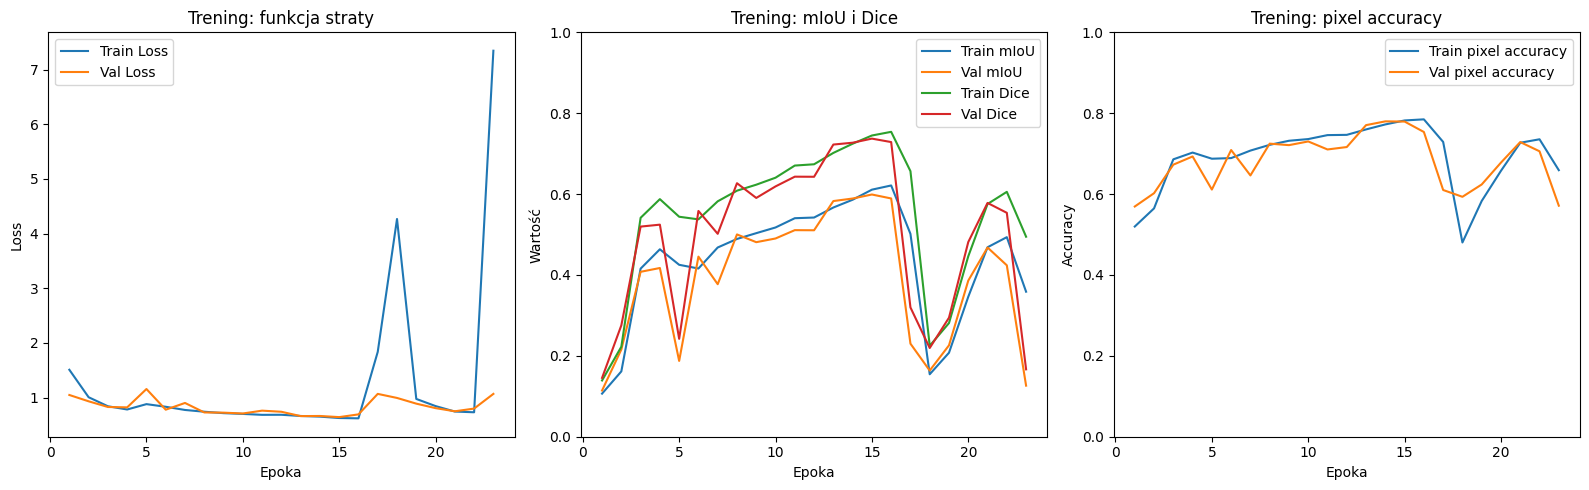

In [13]:
UNet_Aerial_trainer.show_history()

In [14]:
modelUnet.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = modelUnet(images)          # [B, 6, H, W]
    preds = torch.argmax(logits, dim=1) # [B, H, W]

print("images:", images.shape)
print("masks:", masks.shape)
print("logits:", logits.shape)
print("preds:", preds.shape)

print("Mask unique:", masks.unique())
print("Pred unique:", preds.unique())

images: torch.Size([8, 3, 256, 256])
masks: torch.Size([8, 256, 256])
logits: torch.Size([8, 6, 256, 256])
preds: torch.Size([8, 256, 256])
Mask unique: tensor([0, 1, 2, 3, 5], device='cuda:0')
Pred unique: tensor([0, 1, 2, 3, 4], device='cuda:0')


In [15]:
import matplotlib.pyplot as plt
import numpy as np

CLASS_COLORS = {
    0: (60, 16, 152),     # Building
    1: (132, 41, 246),    # Land
    2: (110, 193, 228),   # Road
    3: (254, 221, 58),    # Vegetation
    4: (226, 169, 41),    # Water
    5: (155, 155, 155),   # Unlabeled
}


def class_mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for class_idx, color in CLASS_COLORS.items():
        rgb[mask == class_idx] = color

    return rgb

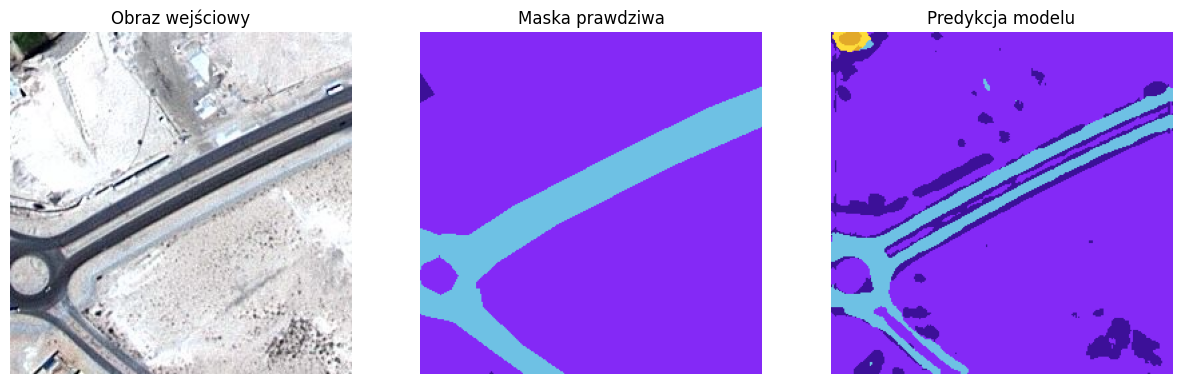

In [16]:
idx = 0

image_np = images[idx].detach().cpu().permute(1, 2, 0).numpy()
mask_np = masks[idx].detach().cpu().numpy()
pred_np = preds[idx].detach().cpu().numpy()

mask_rgb = class_mask_to_rgb(mask_np)
pred_rgb = class_mask_to_rgb(pred_np)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Obraz wejściowy")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_rgb)
plt.title("Maska prawdziwa")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_rgb)
plt.title("Predykcja modelu")
plt.axis("off")

plt.show()

=== Podsumowanie metryk na zbiorze testowym ===


,Metryka,Wartość
0,Loss,0.651618
1,Pixel accuracy,0.776174
2,Mean pixel accuracy,0.746800
3,Mean precision,0.782120
4,Mean recall,0.746800
5,Mean specificity,0.935920
6,Mean F1 / Dice,0.756656
7,Mean IoU,0.620688
8,Weighted F1 / Dice,0.781494
9,Weighted IoU,0.652022


=== Metryki dla poszczególnych klas ===


,Klasa,Piksele GT,Piksele przewidziane,Udział GT [%],Pixel accuracy,Precision,Recall,Specificity,F1 / Dice,IoU / Jaccard
0,Building,939063,1279464,18.853900,0.787267,0.577815,0.787267,0.866350,0.666472,0.499781
1,Land,2542209,2491831,51.040830,0.860191,0.877582,0.860191,0.874906,0.868800,0.768033
2,Road,536267,515729,10.766822,0.626705,0.651662,0.626705,0.959579,0.638940,0.469443
3,Vegetation,783139,562809,15.723359,0.611773,0.851271,0.611773,0.980059,0.711919,0.552697
4,Water,146988,130903,2.951130,0.848062,0.952270,0.848062,0.998707,0.897150,0.813484
5,Unlabeled,33070,0,0.663958,0.000000,NaN,0.000000,1.000000,0.000000,0.000000


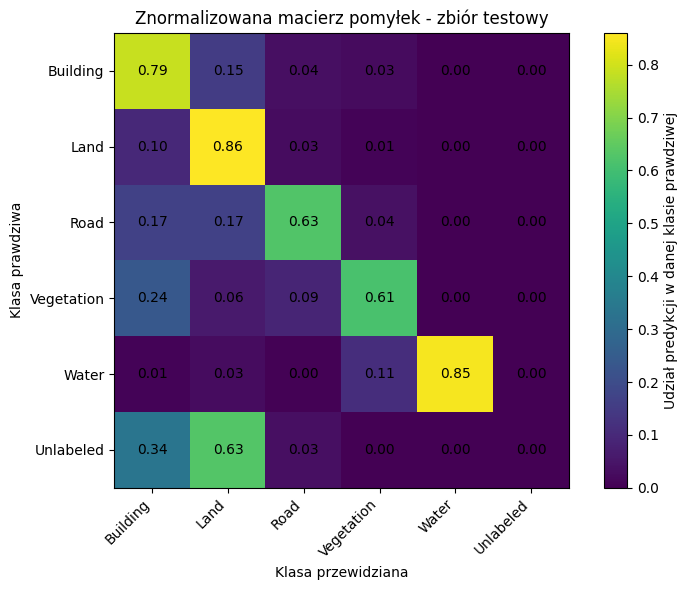

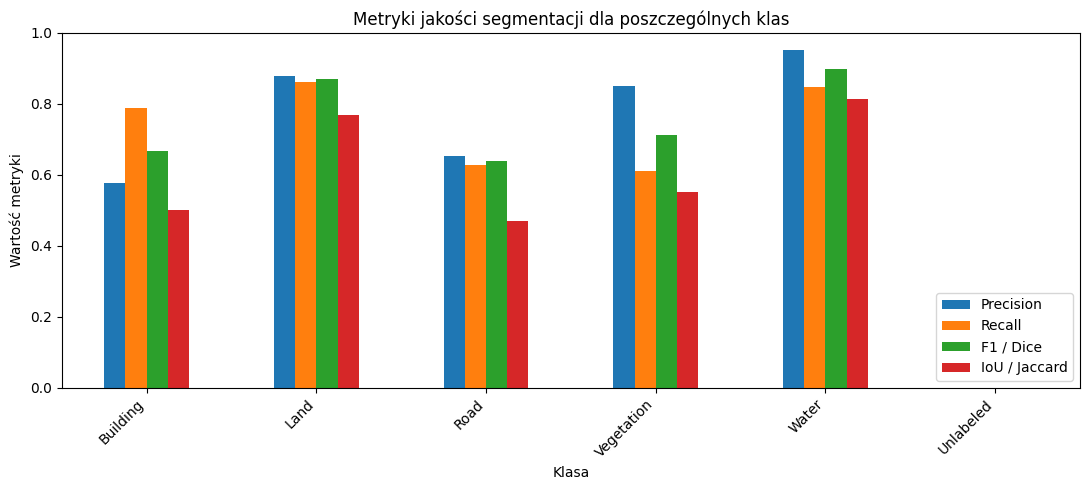

Zapisano pliki:
- metryki_podsumowanie_test.csv
- metryki_klasy_test.csv


In [17]:
# =========================
# Pełna ocena modelu na zbiorze testowym
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt
import csv

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None
    print("Biblioteka pandas nie jest zainstalowana. Wyniki zostaną pokazane jako listy słowników i nadal zapisane do CSV.")

try:
    from IPython.display import display
except ImportError:
    display = print

# Nazwy klas zgodne z kolorami używanymi wcześniej w notebooku
CLASS_NAMES = {
    0: "Building",
    1: "Land",
    2: "Road",
    3: "Vegetation",
    4: "Water",
    5: "Unlabeled",
}

NUM_CLASSES = 6

# Jeżeli klasa 5 oznacza tło/obszar nieopisany, zwykle warto NIE liczyć jej do średnich.
# Jeśli chcesz liczyć wszystkie klasy w średnich, ustaw: IGNORE_CLASS_FOR_MEAN = None
IGNORE_CLASS_FOR_MEAN = 5


def safe_divide(numerator, denominator):
    """Dzielenie odporne na dzielenie przez zero; zwraca NaN tam, gdzie mianownik = 0."""
    numerator = np.asarray(numerator, dtype=np.float64)
    denominator = np.asarray(denominator, dtype=np.float64)
    return np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan, dtype=np.float64),
        where=denominator != 0
    )


def make_table(data):
    if pd is not None:
        return pd.DataFrame(data)
    return data


def display_table(table):
    if pd is not None:
        display(table)
    else:
        for row in table:
            print(row)


def save_table_to_csv(table, path):
    if pd is not None:
        table.to_csv(path, index=False)
        return

    if not table:
        return

    with open(path, "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(table[0].keys()))
        writer.writeheader()
        writer.writerows(table)


def evaluate_segmentation_model(
    model,
    data_loader,
    num_classes=6,
    class_names=None,
    criterion=None,
    device=None,
    ignore_class_for_mean=None,
):
    """
    Liczy metryki dla segmentacji semantycznej:
    - loss,
    - pixel accuracy,
    - mean pixel accuracy,
    - precision,
    - recall,
    - specificity,
    - F1/Dice,
    - IoU/Jaccard,
    - mean IoU,
    - weighted IoU,
    - frequency weighted IoU,
    - Cohen kappa,
    - macierz pomyłek.
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    confusion_matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    total_loss = 0.0
    number_of_batches = 0

    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            if criterion is not None:
                loss = criterion(logits, masks)
                total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            # Spłaszczenie masek i predykcji: [B, H, W] -> [B*H*W]
            true = masks.detach().view(-1).cpu()
            pred = preds.detach().view(-1).cpu()

            # Zabezpieczenie: liczymy tylko piksele o etykietach 0..num_classes-1
            valid = (true >= 0) & (true < num_classes) & (pred >= 0) & (pred < num_classes)
            true = true[valid]
            pred = pred[valid]

            # Wiersze = klasa prawdziwa, kolumny = klasa przewidziana
            encoded = num_classes * true + pred
            confusion_matrix += torch.bincount(
                encoded,
                minlength=num_classes ** 2
            ).reshape(num_classes, num_classes)

            number_of_batches += 1

    cm = confusion_matrix.numpy().astype(np.float64)

    total_pixels = cm.sum()
    tp = np.diag(cm)
    support = cm.sum(axis=1)       # ile pikseli naprawdę należy do danej klasy
    predicted = cm.sum(axis=0)     # ile pikseli model przypisał do danej klasy

    fp = predicted - tp
    fn = support - tp
    tn = total_pixels - tp - fp - fn

    pixel_accuracy = float(safe_divide(tp.sum(), total_pixels))

    expected_accuracy = float(safe_divide(np.sum(support * predicted), total_pixels ** 2))
    cohen_kappa = float(safe_divide(pixel_accuracy - expected_accuracy, 1 - expected_accuracy))

    class_accuracy = safe_divide(tp, support)
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)
    f1_dice = safe_divide(2 * tp, 2 * tp + fp + fn)
    iou = safe_divide(tp, tp + fp + fn)

    valid_classes_for_mean = support > 0
    if ignore_class_for_mean is not None:
        valid_classes_for_mean[ignore_class_for_mean] = False

    mean_pixel_accuracy = np.nanmean(class_accuracy[valid_classes_for_mean])
    mean_precision = np.nanmean(precision[valid_classes_for_mean])
    mean_recall = np.nanmean(recall[valid_classes_for_mean])
    mean_specificity = np.nanmean(specificity[valid_classes_for_mean])
    mean_f1_dice = np.nanmean(f1_dice[valid_classes_for_mean])
    mean_iou = np.nanmean(iou[valid_classes_for_mean])

    class_frequency = safe_divide(support, total_pixels)
    frequency_weighted_iou = np.nansum(class_frequency[valid_classes_for_mean] * iou[valid_classes_for_mean])

    weighted_f1_dice = np.nansum(
        safe_divide(support[valid_classes_for_mean], support[valid_classes_for_mean].sum())
        * f1_dice[valid_classes_for_mean]
    )

    weighted_iou = np.nansum(
        safe_divide(support[valid_classes_for_mean], support[valid_classes_for_mean].sum())
        * iou[valid_classes_for_mean]
    )

    average_loss = None
    if criterion is not None and number_of_batches > 0:
        average_loss = total_loss / number_of_batches

    labels = [
        class_names.get(i, f"Klasa {i}") if class_names is not None else f"Klasa {i}"
        for i in range(num_classes)
    ]

    per_class_rows = []
    for i in range(num_classes):
        per_class_rows.append({
            "Klasa": labels[i],
            "Piksele GT": int(support[i]),
            "Piksele przewidziane": int(predicted[i]),
            "Udział GT [%]": class_frequency[i] * 100,
            "Pixel accuracy": class_accuracy[i],
            "Precision": precision[i],
            "Recall": recall[i],
            "Specificity": specificity[i],
            "F1 / Dice": f1_dice[i],
            "IoU / Jaccard": iou[i],
        })

    summary_rows = [
        {"Metryka": "Loss", "Wartość": average_loss},
        {"Metryka": "Pixel accuracy", "Wartość": pixel_accuracy},
        {"Metryka": "Mean pixel accuracy", "Wartość": mean_pixel_accuracy},
        {"Metryka": "Mean precision", "Wartość": mean_precision},
        {"Metryka": "Mean recall", "Wartość": mean_recall},
        {"Metryka": "Mean specificity", "Wartość": mean_specificity},
        {"Metryka": "Mean F1 / Dice", "Wartość": mean_f1_dice},
        {"Metryka": "Mean IoU", "Wartość": mean_iou},
        {"Metryka": "Weighted F1 / Dice", "Wartość": weighted_f1_dice},
        {"Metryka": "Weighted IoU", "Wartość": weighted_iou},
        {"Metryka": "Frequency weighted IoU", "Wartość": frequency_weighted_iou},
        {"Metryka": "Cohen kappa", "Wartość": cohen_kappa},
    ]

    return make_table(per_class_rows), make_table(summary_rows), cm


# Liczenie metryk na zbiorze testowym
loss_function = nn.CrossEntropyLoss()

per_class_metrics, summary_metrics, confusion_matrix = evaluate_segmentation_model(
    model=modelUnet,
    data_loader=test_loader,
    num_classes=NUM_CLASSES,
    class_names=CLASS_NAMES,
    criterion=loss_function,
    device=device,
    ignore_class_for_mean=IGNORE_CLASS_FOR_MEAN,
)

print("=== Podsumowanie metryk na zbiorze testowym ===")
display_table(summary_metrics)

print("=== Metryki dla poszczególnych klas ===")
display_table(per_class_metrics)


# =========================
# Macierz pomyłek
# =========================

labels = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# Normalizacja po wierszach, czyli względem klas prawdziwych
row_sums = confusion_matrix.sum(axis=1, keepdims=True)
confusion_matrix_normalized = np.divide(
    confusion_matrix,
    row_sums,
    out=np.zeros_like(confusion_matrix, dtype=np.float64),
    where=row_sums != 0
)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix_normalized)
plt.title("Znormalizowana macierz pomyłek - zbiór testowy")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa prawdziwa")
plt.xticks(range(NUM_CLASSES), labels, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), labels)
plt.colorbar(label="Udział predykcji w danej klasie prawdziwej")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, f"{confusion_matrix_normalized[i, j]:.2f}",
                 ha="center", va="center")

plt.tight_layout()
plt.show()


# =========================
# Wykres najważniejszych metryk klasowych
# =========================

metric_names = ["Precision", "Recall", "F1 / Dice", "IoU / Jaccard"]

if pd is not None:
    plot_df = per_class_metrics.set_index("Klasa")[metric_names]
    ax = plot_df.plot(kind="bar", figsize=(11, 5))
    ax.set_title("Metryki jakości segmentacji dla poszczególnych klas")
    ax.set_xlabel("Klasa")
    ax.set_ylabel("Wartość metryki")
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    x = np.arange(NUM_CLASSES)
    width = 0.2

    plt.figure(figsize=(11, 5))
    for idx, metric_name in enumerate(metric_names):
        values = [row[metric_name] for row in per_class_metrics]
        plt.bar(x + (idx - 1.5) * width, values, width=width, label=metric_name)

    plt.title("Metryki jakości segmentacji dla poszczególnych klas")
    plt.xlabel("Klasa")
    plt.ylabel("Wartość metryki")
    plt.ylim(0, 1)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


# =========================
# Zapis wyników do plików CSV
# =========================

save_table_to_csv(summary_metrics, "metryki_podsumowanie_test.csv")
save_table_to_csv(per_class_metrics, "metryki_klasy_test.csv")

print("Zapisano pliki:")
print("- metryki_podsumowanie_test.csv")
print("- metryki_klasy_test.csv")
